# Notebook 03 — Exploratory Data Analysis

**Run after:** 02_preprocessing.ipynb

**What this does:** Creates all analysis charts

In [1]:
# CELL 1 - Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/processed/gtd_processed.csv', low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

# Check what era values actually exist in the data
if 'era' in df.columns:
    print(f'\nEra values in data:')
    print(df['era'].value_counts().to_string())

IDEOLOGY_COLORS = {
    'Religious Extremist': '#e74c3c',
    'Ethno-Nationalist':   '#3498db',
    'Left-Wing':           '#e67e22',
    'Right-Wing':          '#9b59b6',
    'Single Issue':        '#2ecc71',
    'Unknown':             '#95a5a6',
}

Loaded: 181,691 rows x 23 columns
Columns: ['year', 'month', 'day', 'country', 'region', 'city', 'attack_type', 'target_type', 'group_name', 'killed', 'wounded', 'weapon_type', 'success', 'suicide', 'latitude', 'longitude', 'ideology', 'religion_subtype', 'total_casualties', 'severity_score', 'is_mass_casualty', 'decade', 'era']

Era values in data:
era
ISIS Rise         47363
Recent 2015+      39452
Cold War 1980s    31160
Post-Cold War     30576
Post 9/11         23226
Cold War 1970s     9914


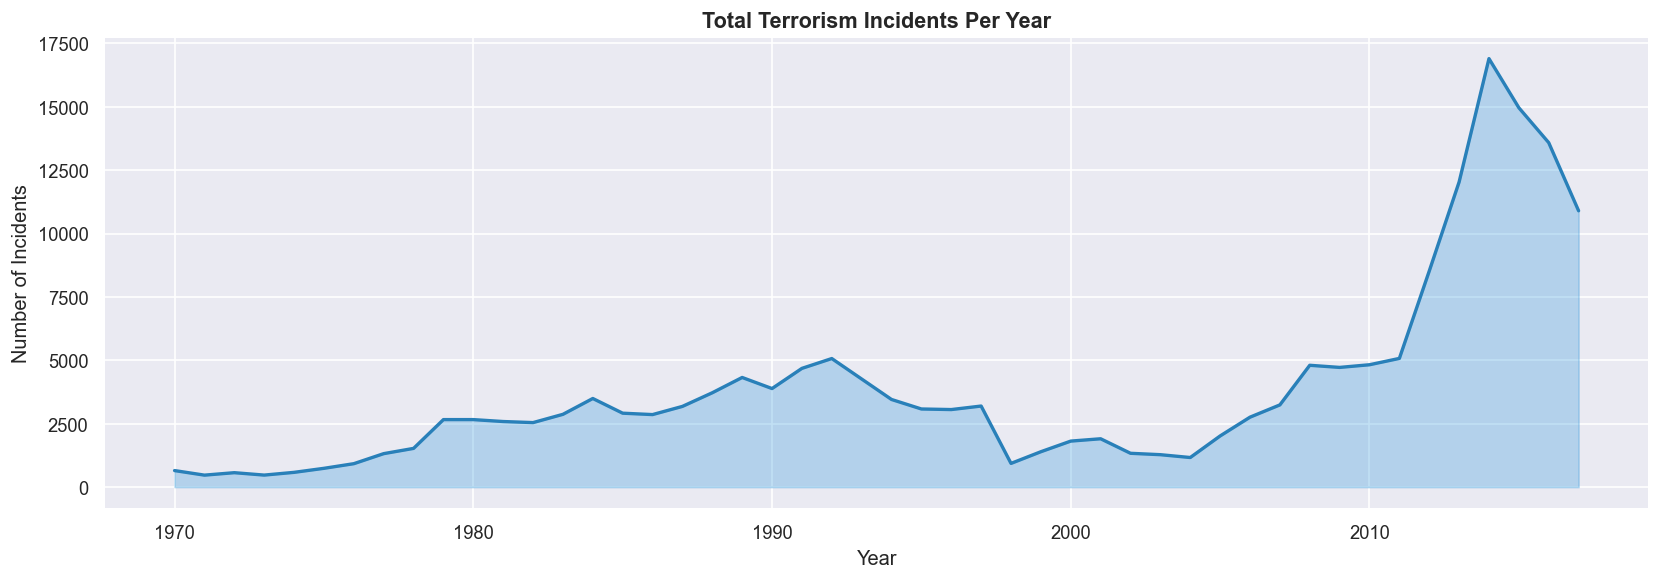

Chart saved.


In [2]:
# CELL 2 - Attacks per year
year_col = 'year' if 'year' in df.columns else 'iyear'
yearly = df.groupby(year_col).size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly.index, yearly.values, alpha=0.3, color='#3498db')
ax.plot(yearly.index, yearly.values, color='#2980b9', linewidth=2)
ax.set_title('Total Terrorism Incidents Per Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
plt.tight_layout()
plt.savefig('../data/processed/eda_yearly.png', dpi=150)
plt.show()
print('Chart saved.')

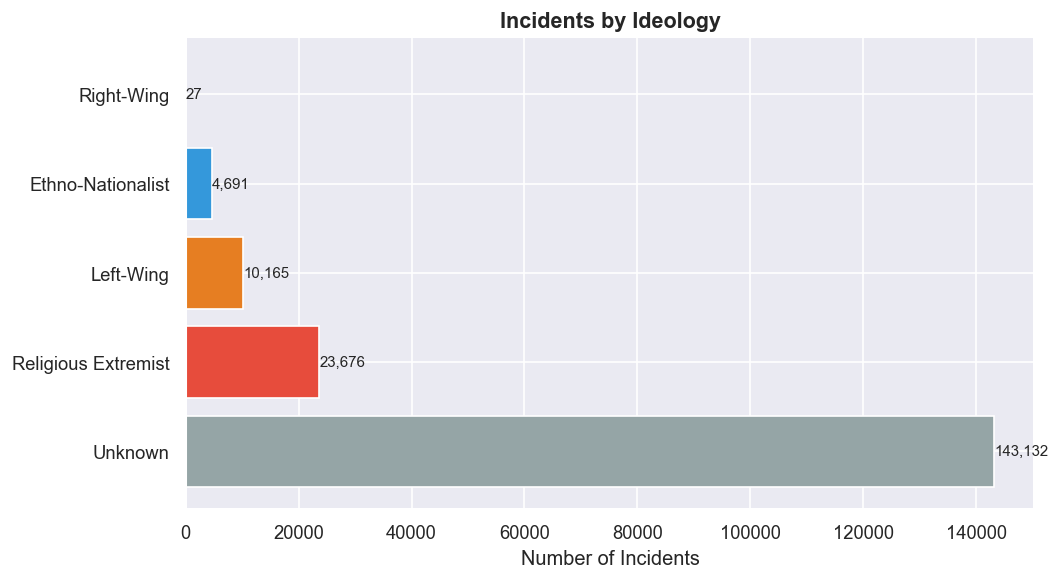

Chart saved.


In [3]:
# CELL 3 - Ideology bar chart
counts = df['ideology'].value_counts()
colors = [IDEOLOGY_COLORS.get(i, '#bdc3c7') for i in counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_title('Incidents by Ideology', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Incidents')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/eda_ideology.png', dpi=150)
plt.show()
print('Chart saved.')

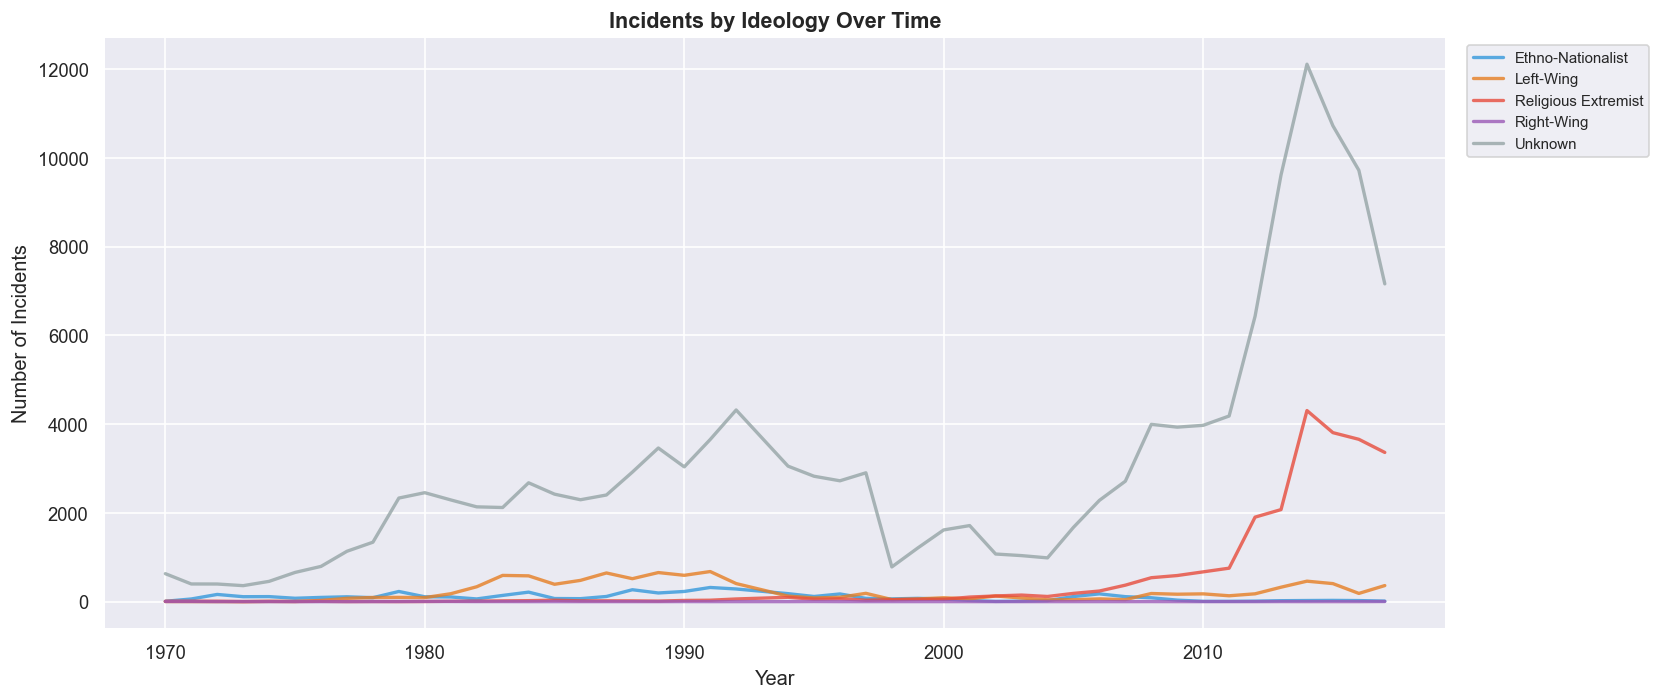

Chart saved.


In [4]:
# CELL 4 - Ideology over time (line chart)
year_col = 'year' if 'year' in df.columns else 'iyear'

pivot = df.groupby([year_col, 'ideology']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
for ideology in pivot.columns:
    color = IDEOLOGY_COLORS.get(ideology, '#bdc3c7')
    ax.plot(pivot.index, pivot[ideology], label=ideology,
            color=color, linewidth=2, alpha=0.8)

ax.set_title('Incidents by Ideology Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/eda_ideology_time.png', dpi=150)
plt.show()
print('Chart saved.')

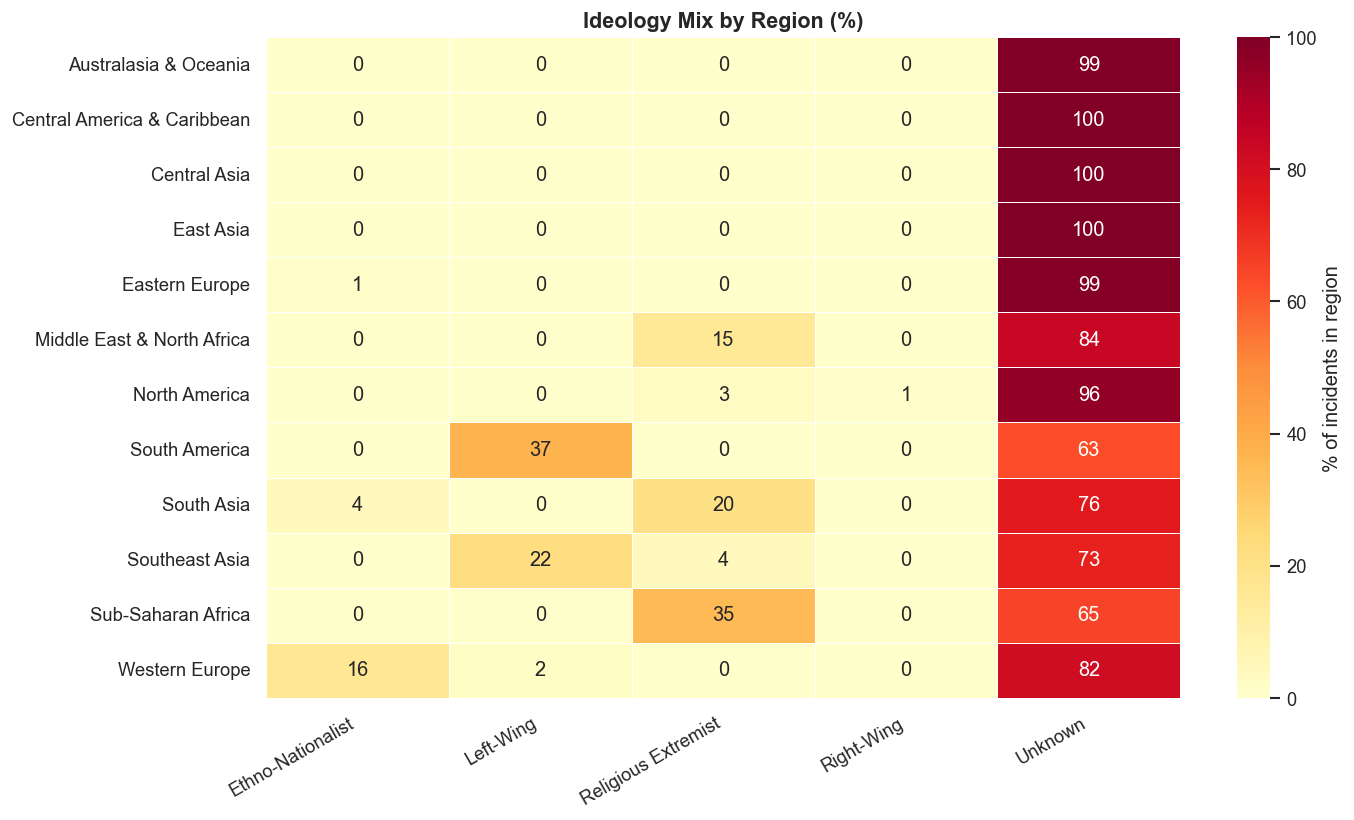

Chart saved.


In [5]:
# CELL 5 - Region heatmap
region_col = 'region' if 'region' in df.columns else 'region_txt'

if region_col in df.columns:
    hm = df.groupby([region_col, 'ideology']).size().unstack(fill_value=0)
    hm_pct = hm.div(hm.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(hm_pct, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=ax,
                cbar_kws={'label': '% of incidents in region'})
    ax.set_title('Ideology Mix by Region (%)', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('../data/processed/eda_heatmap.png', dpi=150)
    plt.show()
    print('Chart saved.')
else:
    print('Region column not found — skipping heatmap')

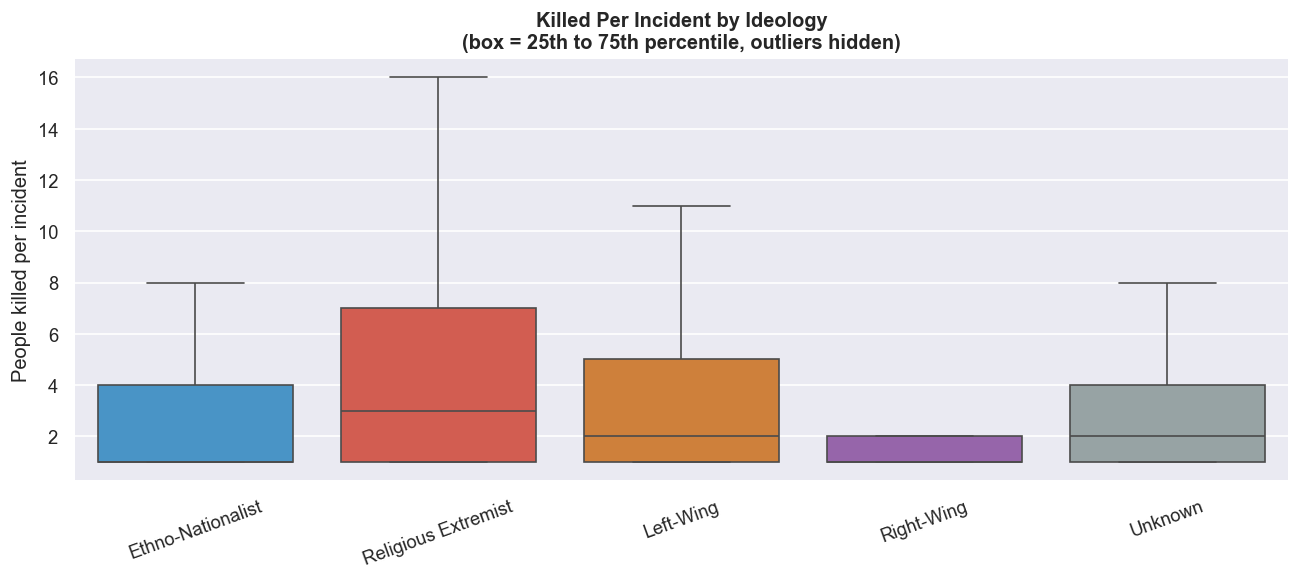

Chart saved.


In [6]:
# CELL 6 - Casualties by ideology box plot
kill_col = 'killed' if 'killed' in df.columns else 'nkill'

if kill_col in df.columns:
    nonzero = df[df[kill_col] > 0].copy()
    order = df.groupby('ideology')[kill_col].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.boxplot(data=nonzero, x='ideology', y=kill_col,
                order=order, palette=IDEOLOGY_COLORS,
                showfliers=False, ax=ax)
    ax.set_title('Killed Per Incident by Ideology\n(box = 25th to 75th percentile, outliers hidden)',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('People killed per incident')
    ax.set_xlabel('')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig('../data/processed/eda_casualties.png', dpi=150)
    plt.show()
    print('Chart saved.')

Era values found in data: ['Cold War 1970s', 'Cold War 1980s', 'Post-Cold War', 'Post 9/11', 'ISIS Rise', 'Recent 2015+']
Using era order: ['Cold War 1970s', 'Cold War 1980s', 'Post-Cold War', 'Post 9/11', 'ISIS Rise', 'Recent 2015+']


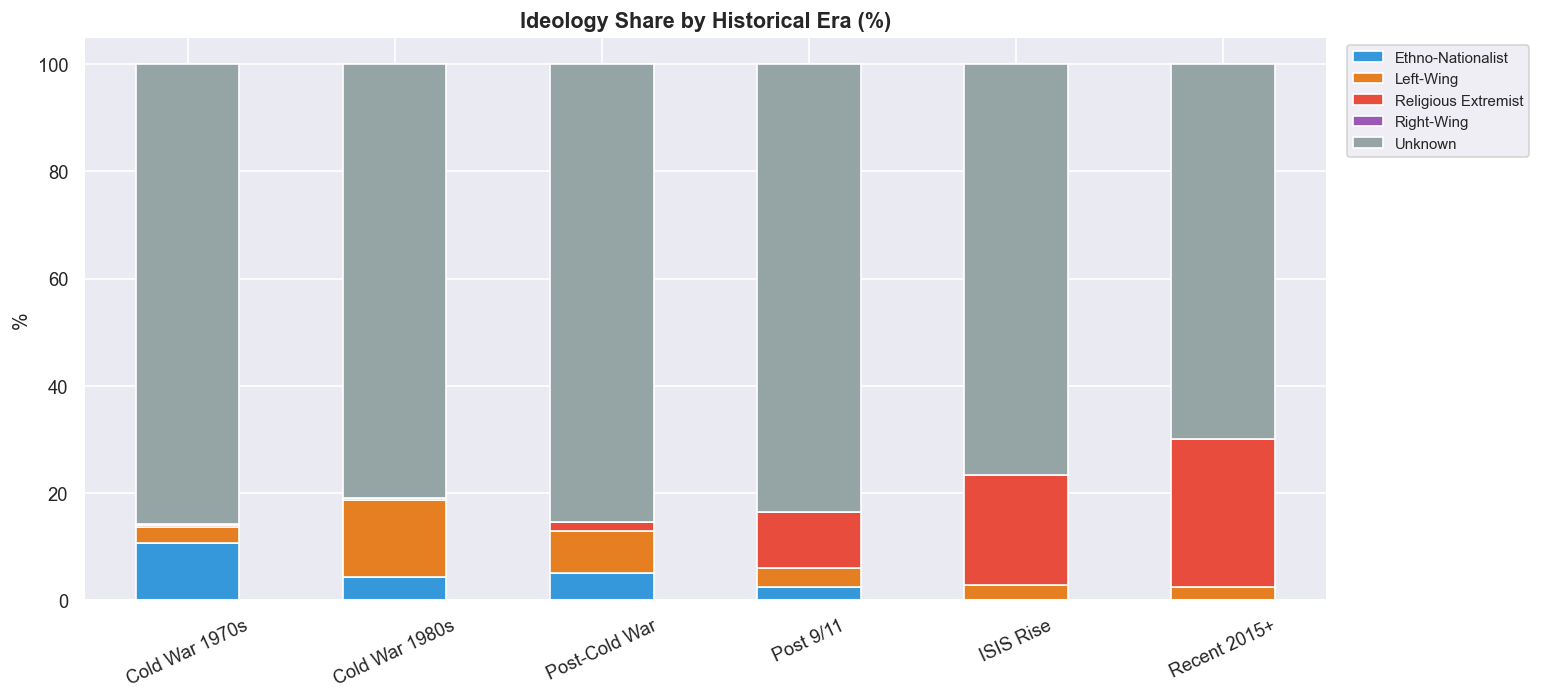

Chart saved.

Cold War 1970s-80s: Left-Wing + Ethno-Nationalist dominated
Post 9/11: Religious Extremist share grew sharply
Recent 2015+: Right-Wing share rising in Western countries


In [7]:
# CELL 7 - Era analysis (FIXED - uses actual era names from your data)

if 'era' in df.columns:
    # Step 1: see exactly what era values exist in YOUR data
    actual_eras = df['era'].dropna().unique().tolist()
    print(f'Era values found in data: {actual_eras}')

    # Step 2: build the pivot table
    era_pct = (
        df.groupby(['era', 'ideology'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda x: x / x.sum() * 100, axis=1)
    )

    # Step 3: sort eras in the correct order
    # These match exactly what 02_preprocessing.ipynb creates
    preferred_order = [
        'Cold War 1970s',
        'Cold War 1980s',
        'Post-Cold War',
        'Post 9/11',
        'ISIS Rise',
        'Recent 2015+'
    ]

    # Only keep eras that actually exist in the data
    final_order = [e for e in preferred_order if e in era_pct.index]

    # If none of those match, just use whatever order exists
    if len(final_order) == 0:
        final_order = list(era_pct.index)
        print(f'Using era order from data: {final_order}')
    else:
        print(f'Using era order: {final_order}')

    era_pct = era_pct.reindex(final_order)

    # Step 4: drop any completely empty rows
    era_pct = era_pct.dropna(how='all')

    if len(era_pct) == 0:
        print('No era data to plot after filtering.')
    else:
        # Step 5: plot
        colors = [IDEOLOGY_COLORS.get(c, '#bdc3c7') for c in era_pct.columns]
        ax = era_pct.plot(
            kind='bar', stacked=True,
            figsize=(13, 6), color=colors
        )
        ax.set_title('Ideology Share by Historical Era (%)', fontweight='bold', fontsize=13)
        ax.set_ylabel('%')
        ax.set_xlabel('')
        ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.savefig('../data/processed/eda_era.png', dpi=150)
        plt.show()
        print('Chart saved.')
        print('\nCold War 1970s-80s: Left-Wing + Ethno-Nationalist dominated')
        print('Post 9/11: Religious Extremist share grew sharply')
        print('Recent 2015+: Right-Wing share rising in Western countries')
else:
    print('era column not found — run 02_preprocessing.ipynb first')

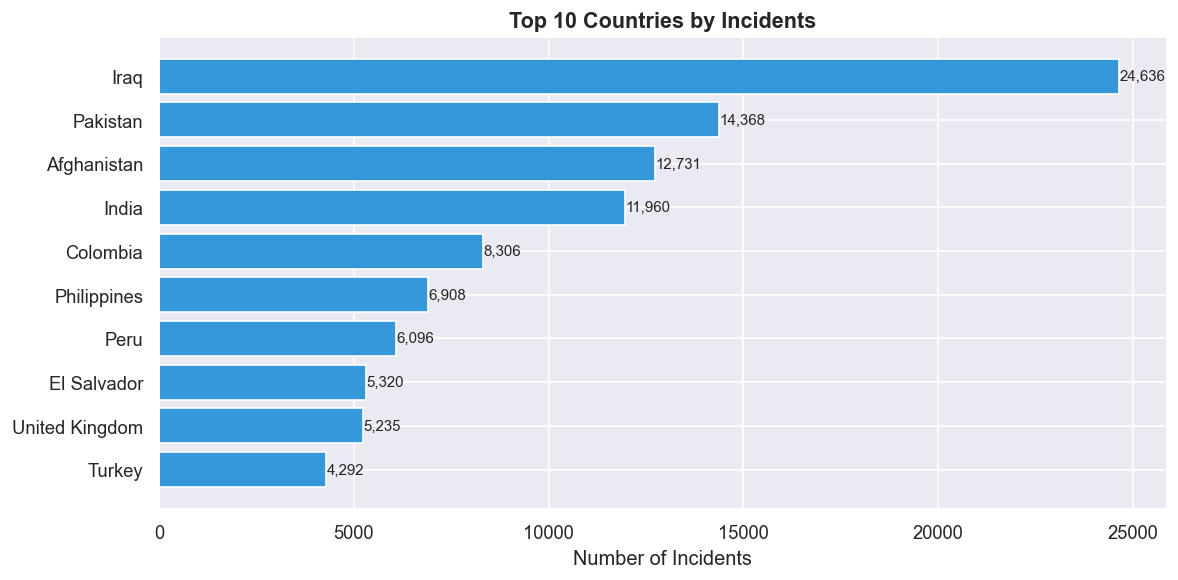

Chart saved.


In [8]:
# CELL 8 - Top 10 countries by incidents
country_col = 'country' if 'country' in df.columns else 'country_txt'

if country_col in df.columns:
    top_countries = df[country_col].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color='#3498db')
    ax.set_title('Top 10 Countries by Incidents', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Incidents')
    for bar, val in zip(bars, top_countries.values[::-1]):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../data/processed/eda_countries.png', dpi=150)
    plt.show()
    print('Chart saved.')

In [9]:
# CELL 9 - Summary statistics table
kill_col = 'killed' if 'killed' in df.columns else 'nkill'

summary = df.groupby('ideology').agg(
    incidents=('ideology', 'count'),
    total_killed=(kill_col, 'sum'),
    avg_killed=(kill_col, 'mean'),
    median_killed=(kill_col, 'median')
).round(2).sort_values('incidents', ascending=False)

print('=== SUMMARY STATISTICS BY IDEOLOGY ===')
print(summary.to_string())
print('\nAll charts saved to data/processed/')
print('EDA complete. Next -> run backend/app.py and frontend')

=== SUMMARY STATISTICS BY IDEOLOGY ===
                     incidents  total_killed  avg_killed  median_killed
ideology                                                               
Unknown                 143132        256570        1.79            0.0
Religious Extremist      23676        119714        5.06            1.0
Left-Wing                10165         22142        2.18            0.0
Ethno-Nationalist         4691         13434        2.86            1.0
Right-Wing                  27             8        0.30            0.0

All charts saved to data/processed/
EDA complete. Next -> run backend/app.py and frontend
